In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv("Poulamibhowmick5084.csv")

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nFirst 5 rows:")
df.head()

Shape: (71478, 22)

Columns: ['Row ID', 'Order ID', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Regional Manager', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Returned', 'Sales', 'Quantity', 'Discount', 'Profit', 'Order']

First 5 rows:


C:\Users\poula\AppData\Local\Temp\ipykernel_8452\3307279260.py:10: DtypeWarning: Columns (0: Postal Code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Poulamibhowmick5084.csv")


,Row ID,Order ID,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,...,Product ID,Category,Sub-Category,Product Name,Returned,Sales,Quantity,Discount,Profit,Order
0,1,CA-2016-152156,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,No,261.9600,2,0.00,41.9136,08/11/2016
1,2,CA-2016-152156,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",No,731.9400,3,0.00,219.5820,08/11/2016
2,3,CA-2016-138688,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,No,14.6200,2,0.00,6.8714,12/06/2016
3,4,US-2015-108966,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,No,957.5775,5,0.45,-383.0310,11/10/2015
4,5,US-2015-108966,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,No,22.3680,2,0.20,2.5164,11/10/2015


In [3]:
df['Order'] = pd.to_datetime(df['Order'], dayfirst=True)
df['Year'] = df['Order'].dt.year
df[['Order', 'Year']].head()

,Order,Year
0,2016-11-08,2016
1,2016-11-08,2016
2,2016-06-12,2016
3,2015-10-11,2015
4,2015-10-11,2015


In [4]:
subcat_summary = df.groupby(['Category', 'Sub-Category']).agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()

subcat_summary

,Category,Sub-Category,Sales,Profit
0,Furniture,Bookcases,1.696813e+06,154819.78990
1,Furniture,Chairs,2.165899e+06,194209.96610
2,Furniture,Furnishings,5.728815e+05,73918.31210
3,Furniture,Tables,1.172028e+06,-99562.07590
4,Office Supplies,Appliances,1.226810e+06,178148.07920
5,Office Supplies,Art,4.268698e+05,71134.89410
6,Office Supplies,Binders,8.726791e+05,134097.70960
7,Office Supplies,Envelopes,2.039091e+05,43553.31770
8,Office Supplies,Fasteners,9.479884e+04,14903.57810
9,Office Supplies,Labels,9.858538e+04,26129.54400


In [5]:
print(df['Year'].unique())

[2016 2015 2014 2017 2018 2019 2020 2021 2012 2013 2011]


In [6]:
yearly_sales = df.groupby(['Year', 'Sub-Category'])['Sales'].sum().unstack(fill_value=0)

yearly_sales

Sub-Category,Accessories,Appliances,Art,Binders,Bookcases,Chairs,Copiers,Envelopes,Fasteners,Furnishings,Labels,Machines,Paper,Phones,Storage,Supplies,Tables
Year,,,,,,,,,,,,,,,,,
2011,113456.0076,173383.4264,64138.9322,86998.9143,259396.2858,285730.9761,216367.89214,27986.6005,13608.5666,63933.6284,13616.4576,160545.6814,42665.9781,337282.4802,205626.9622,47580.6123,147131.4937
2012,172397.6850,222942.9649,82358.3492,93417.9158,317953.4498,295058.1396,327168.59880,38013.8195,19477.6939,81804.4719,15518.2708,159858.9511,51512.3793,364016.2744,228555.8172,43297.4164,164086.4968
2013,209895.1623,254951.1295,98007.0331,121075.0913,376025.7999,427514.3732,415514.88858,50805.2553,21596.8929,111819.8452,18380.7895,198376.1987,70512.5548,453519.0045,309475.7954,65913.1001,202363.5351
2014,278502.4356,375100.4092,133645.6334,203907.8493,533233.3839,570619.8513,561234.67576,57954.3763,29220.4905,141846.5444,28729.9061,322302.6089,94435.7632,629397.1861,433756.3286,100677.1618,289548.7643
2015,40523.9600,23241.2890,6236.8340,37453.0980,38543.5725,71734.5290,26179.45000,4512.1880,545.2240,21089.7120,2956.4620,27763.6970,15287.6380,68313.7020,45048.2480,1952.4820,39150.4235
2016,41895.8540,26050.3150,5960.9080,49683.3250,26275.4665,83918.6450,49599.41000,4729.8900,960.1340,27874.1240,2827.2400,55906.8860,20661.8940,78962.0300,58788.7000,14277.5760,60833.2005
2017,59946.2320,42926.9320,8863.0680,72788.0450,30024.2797,95554.3530,62899.38800,3378.5740,857.5940,28915.0940,3861.2160,43544.6750,27694.7180,105340.5160,69677.6180,16049.4100,60893.5425
2018,25014.2720,15689.2250,6154.5260,44460.2690,20036.6776,79982.4760,12049.76200,3855.7500,801.1680,15090.1100,2841.3940,62366.5730,15321.7180,78470.8260,50470.1400,14419.7800,47015.5455
2019,40523.9600,23248.5690,6362.0260,37663.2100,38543.5725,72673.9650,26179.45000,4548.6280,567.4240,21942.7360,2956.4620,27763.6970,15316.4860,68525.4120,45054.9280,1952.4820,39170.0235


In [13]:
sales_diff = yearly_sales.loc[2021] - yearly_sales.loc[2020]
sales_diff = sales_diff.sort_values()
sales_diff

Sub-Category
Machines      -12019.0110
Envelopes      -1366.8360
Tables           163.7920
Labels          1076.8660
Furnishings     1289.2720
Supplies        1798.0840
Art             2902.9300
Bookcases       3927.1932
Fasteners       5159.7800
Paper           7444.7260
Storage        11428.1340
Chairs         12952.9460
Copiers        13317.2580
Appliances     16946.9210
Accessories    18050.3780
Binders        22071.1360
Phones         26490.3820
dtype: float64

# Total Sales and Profit by Sub-Category

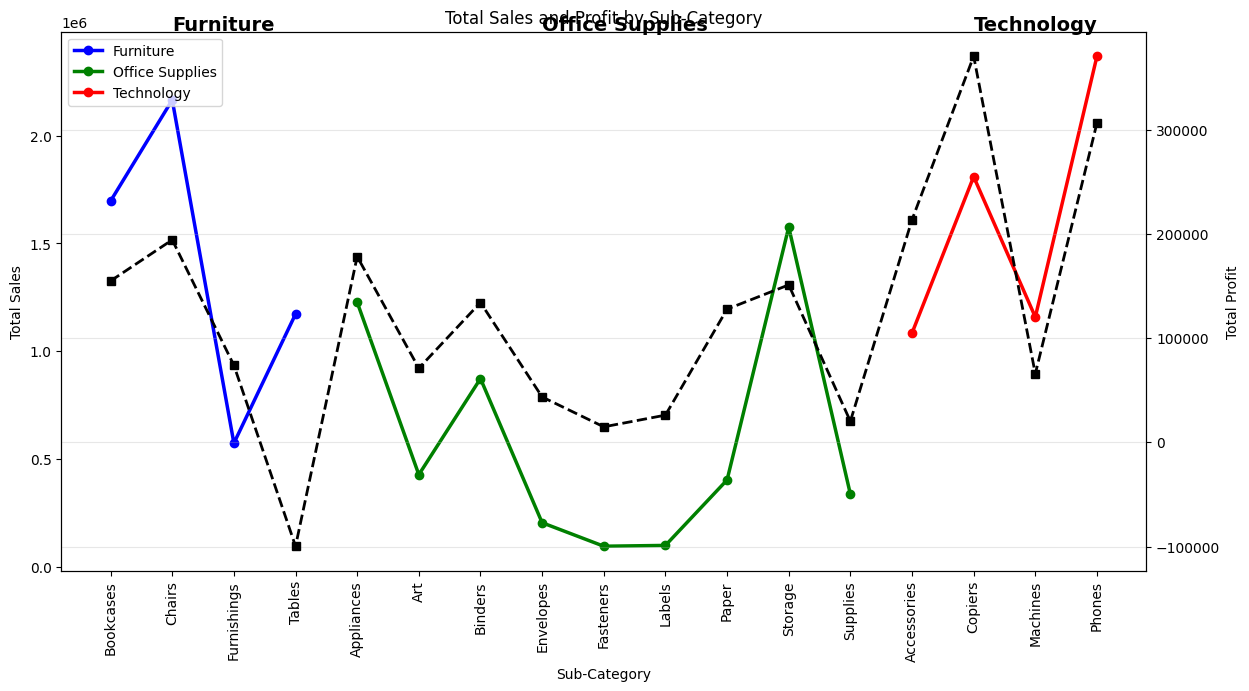

In [8]:

fig, ax1 = plt.subplots(figsize=(14, 7))

category_colors = {
    'Furniture': 'blue',
    'Office Supplies': 'green',
    'Technology': 'red'
}


x_labels = subcat_summary['Sub-Category']
x = np.arange(len(x_labels))


for category in subcat_summary['Category'].unique():
    cat_data = subcat_summary[subcat_summary['Category'] == category]
    
    ax1.plot(
        cat_data['Sub-Category'],
        cat_data['Sales'],
        marker='o',
        linewidth=2.5,
        label=category,
        color=category_colors[category]
    )


ax1.set_xlabel("Sub-Category")
ax1.set_ylabel("Total Sales")
ax1.tick_params(axis='x', rotation=90)


ax2 = ax1.twinx()

ax2.plot(
    x_labels,
    subcat_summary['Profit'],
    linestyle='--',
    marker='s',
    color='black',
    linewidth=2,
    label='Profit'
)

ax2.set_ylabel("Total Profit")

ax1.text(1, max(subcat_summary['Sales']) * 1.05, "Furniture", fontsize=14, weight='bold')
ax1.text(7, max(subcat_summary['Sales']) * 1.05, "Office Supplies", fontsize=14, weight='bold')
ax1.text(14, max(subcat_summary['Sales']) * 1.05, "Technology", fontsize=14, weight='bold')
plt.title("Total Sales and Profit by Sub-Category")

ax1.legend(loc='upper left')

plt.grid(alpha=0.3)
plt.show()

## Interpretation

This visualization compares total sales and total profit across different product sub-categories.

- The line graph represents sales performance.
- The dotted line represents profit trends.
- Different colors indicate different product categories.

## Observations

- Technology category shows high sales and profit.
- Some sub-categories generate high sales but lower profit.
- Furniture category shows fluctuations in profitability.
- Office Supplies maintain moderate and stable performance.

## Conclusion

The graph helps identify profitable and non-profitable sub-categories and supports better business decision-making.

 # Sales Difference Between 2020 and 2021

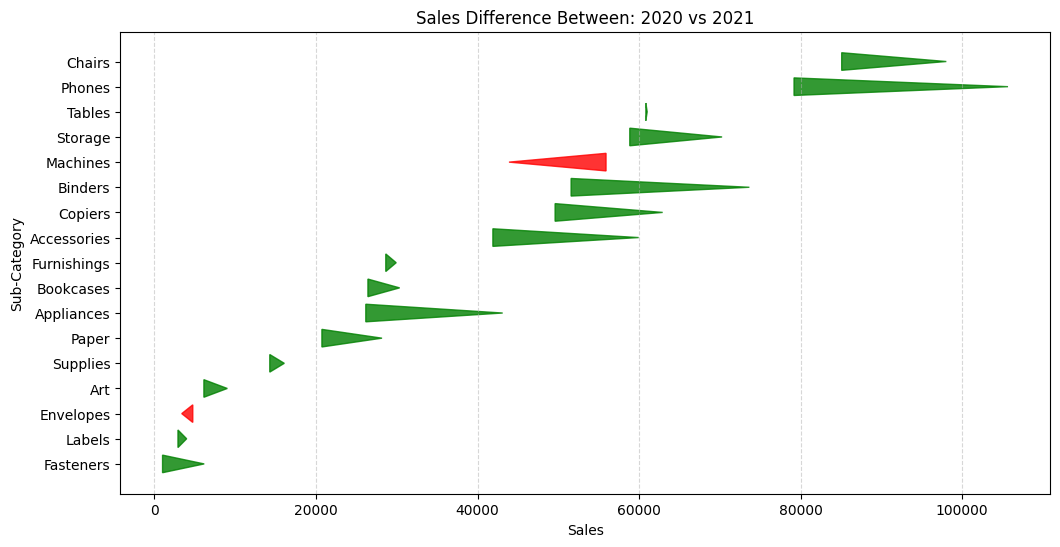

In [9]:

sales_2020 = yearly_sales.loc[2020]
sales_2021 = yearly_sales.loc[2021]


sales_diff = sales_2021 - sales_2020


sales_2020 = sales_2020.sort_values()
sales_2021 = sales_2021[sales_2020.index]
sales_diff = sales_diff[sales_2020.index]

plt.figure(figsize=(12,6))

for i, subcat in enumerate(sales_2020.index):

    start = sales_2020[subcat]
    end = sales_2021[subcat]

    if end > start:
        color = 'green'
    else:
        color = 'red'

    
    x_points = [start, start, end]
    y_points = [i-0.35, i+0.35, i]

    plt.fill(x_points, y_points, color=color, alpha=0.8)


plt.yticks(range(len(sales_2020.index)), sales_2020.index)
plt.xlabel("Sales")
plt.ylabel("Sub-Category")
plt.title("Sales Difference Between: 2020 vs 2021")


plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()

## Interpretation

This visualization compares sales performance of different sub-categories between 2020 and 2021.

- Green arrows indicate increase in sales.
- Red arrows indicate decrease in sales.
- The direction and length of arrows represent the magnitude of change.

## Observations

- Some sub-categories showed significant sales growth in 2021.
- Technology-related products performed strongly.
- Certain sub-categories experienced decline in sales.
- The graph helps identify high-performing and low-performing product groups.

## Conclusion

The comparison shows changing customer demand patterns between the two years and helps in understanding business performance trends.

# TIME SERIES ANALYSIS

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt


X = df[['Sales']]
y = df['Profit']

model = LinearRegression()

model.fit(X, y)

y_pred = model.predict(X)
r2 = r2_score(y, y_pred)

print("R² Score:", r2)


slope = model.coef_[0]
intercept = model.intercept_

print(f"Regression Equation:")
print(f"Profit = {slope:.4f} * Sales + {intercept:.4f}")

R² Score: 0.23314965320979153
Regression Equation:
Profit = 0.1761 * Sales + -13.9008


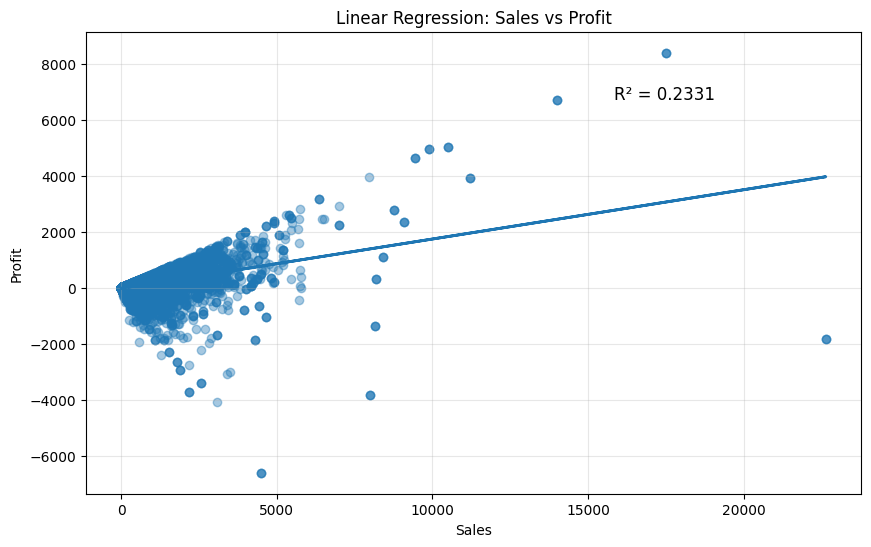

In [11]:
plt.figure(figsize=(10,6))

plt.scatter(X['Sales'], y, alpha=0.4)
plt.plot(X['Sales'], y_pred, linewidth=2)

plt.xlabel("Sales")
plt.ylabel("Profit")
plt.title("Linear Regression: Sales vs Profit")

plt.text(
    X['Sales'].max()*0.7,
    y.max()*0.8,
    f'R² = {r2:.4f}',
    fontsize=12
)
plt.grid(alpha=0.3)
plt.show()

# Linear Regression output Analysis

## Interpretation
- The regression model studies the relationship between Sales and Profit.
- The regression line shows the trend of profit as sales increase.
- A positive slope indicates that profit generally increases with sales.
- The R² score measures the strength of the relationship.

## Observation
- Higher sales mostly lead to higher profits.
- Some transactions may still show low or negative profit despite high sales.
- The relationship is moderately positive.

# TIME SERIES ANALYSIS

In [30]:
df.reset_index(inplace=True)

In [31]:
df['Order'] = pd.to_datetime(df['Order'], dayfirst=True)

In [32]:
df.set_index('Order', inplace=True)

In [33]:
monthly_sales = df.resample('ME')['Sales'].sum()

In [34]:
monthly_sales.head()

Order
2011-01-31     98898.48886
2011-02-28     91152.15698
2011-03-31    145729.36736
2011-04-30    116915.76418
2011-05-31    146747.83610
Freq: ME, Name: Sales, dtype: float64

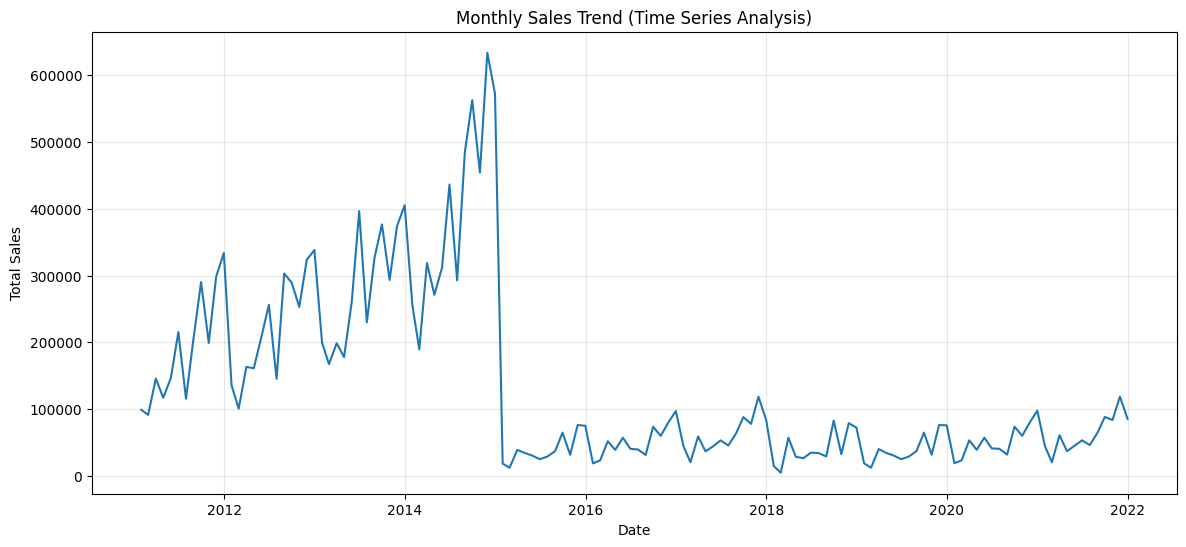

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(monthly_sales)

plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trend (Time Series Analysis)")

plt.grid(alpha=0.3)

plt.show()

In [36]:
rolling_avg = monthly_sales.rolling(window=3).mean()

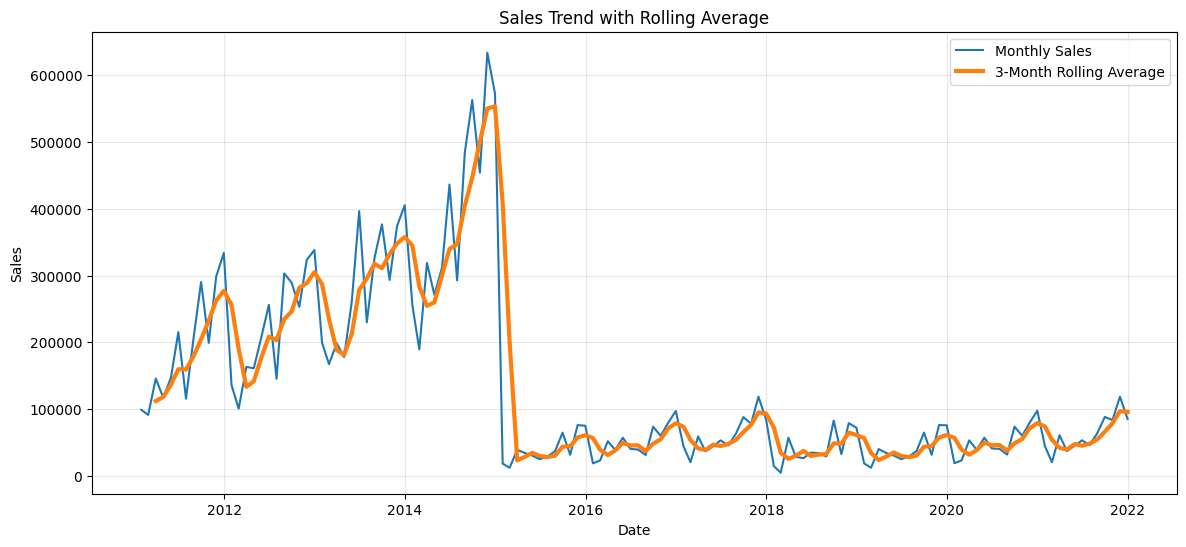

In [37]:
plt.figure(figsize=(14,6))

plt.plot(monthly_sales, label='Monthly Sales')

plt.plot(
    rolling_avg,
    linewidth=3,
    label='3-Month Rolling Average'
)

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Sales Trend with Rolling Average")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

# Time Series Analysis Interpretation

## Interpretation
- Time Series Analysis studies how sales change over time.
- Monthly sales trends help identify growth and fluctuations.
- Rolling averages smooth short-term variations and highlight long-term trends.

## Observations
- Sales generally show upward movement over time.
- Some periods show sudden spikes or declines.
- The rolling average indicates overall business growth trend.


# Final Report

# Introduction

This project focuses on analyzing a retail sales dataset using data visualization, Linear Regression, and Time Series Analysis techniques.

The objective of the analysis is to identify business trends, understand the relationship between sales and profit, and examine sales performance over time.

The dataset contains information related to:

- Order Date
- Product Categories
- Sub-Categories
- Sales
- Profit
- Quantity
- Regional Performance

Python libraries such as Pandas, Matplotlib, NumPy, and Scikit-learn were used for data analysis and visualization.

# Objectives

- Perform exploratory data analysis on sales dataset
- Visualize sales and profit trends
- Analyze yearly sales differences across sub-categories
- Build a Linear Regression model between Sales and Profit
- Perform Time Series Analysis on monthly sales trends
- Generate business insights from data

# Data Visualization

Data visualization techniques were used to understand patterns and trends in the dataset.

The following visualizations were created:

1. Sales Difference Between 2020 and 2021
2. Total Sales and Profit by Sub-Category
3. Monthly Sales Trend
4. Rolling Average Trend

These visualizations helped identify high-performing categories, declining product groups, and overall sales behavior over time.

# Linear Regression Analysis

## Objective

Linear Regression was used to analyze the relationship between Sales and Profit.

- Independent Variable: Sales
- Dependent Variable: Profit

The regression model predicts profit values based on sales performance.

## Methodology

A Linear Regression model was built using Scikit-learn.

The following were generated:

- Regression Line
- Predicted Values
- R² Score
- Regression Equation

## Observations

- Sales and Profit show a positive relationship.
- Higher sales generally lead to increased profit.
- Some transactions show low profitability despite high sales.

## Conclusion

Linear Regression helps evaluate profitability trends and supports data-driven business decisions.

# Time Series Analysis

## Objective

Time Series Analysis was performed to study sales trends over time using Order Date and Sales columns.

## Methodology

Monthly sales data was generated by resampling sales records using date-based indexing.

The following visualizations were created:

- Monthly Sales Trend
- Rolling Average Trend
- Yearly Sales Trend

## Observations

- Sales fluctuate across different time periods.
- Rolling averages help identify long-term trends.
- Overall sales performance shows gradual business growth.

## Conclusion

Time Series Analysis helps identify growth patterns, fluctuations, and long-term sales behavior.

# Key Insights

- Technology category showed strong sales and profit performance.
- Some sub-categories experienced declining yearly sales.
- Sales and profit are positively correlated.
- Monthly sales trends indicate business growth with periodic fluctuations.
- Data visualization improved understanding of product performance and business trends.

# Tools and Technologies Used

- Python
- Jupyter Notebook
- Pandas
- NumPy
- Matplotlib
- Scikit-learn

# Final Conclusion

This project successfully analyzed retail sales data using visualization, Linear Regression, and Time Series Analysis techniques.

The analysis provided insights into:

- Sales growth trends
- Profitability patterns
- Product category performance
- Long-term sales behavior

The project demonstrates the application of data analytics and machine learning techniques for business insight generation and decision-making.